In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv("/content/drive/MyDrive/Statistics/ab_data.csv")
data

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2017-01-03 22:28:38.630509,control,old_page,0
294474,945152,2017-01-12 00:51:57.078372,control,old_page,0
294475,734608,2017-01-22 11:45:03.439544,control,old_page,0
294476,697314,2017-01-15 01:20:28.957438,control,old_page,0


In [5]:
print(f"Data's Shape : {data.shape}")

Data's Shape : (294478, 5)


In [8]:
print(type(data["converted"]))
print(data["converted"].mean())
print(data["converted"].unique())

<class 'pandas.core.series.Series'>
0.11965919355605512
[0 1]


In [10]:
data.nunique()

,0
user_id,290584
timestamp,294478
group,2
landing_page,2
converted,2


In [12]:
data.query("group == 'treatment' and landing_page != 'new_page'")

,user_id,timestamp,group,landing_page,converted
308,857184,2017-01-20 07:34:59.832626,treatment,old_page,0
327,686623,2017-01-09 14:26:40.734775,treatment,old_page,0
357,856078,2017-01-12 12:29:30.354835,treatment,old_page,0
685,666385,2017-01-23 08:11:54.823806,treatment,old_page,0
713,748761,2017-01-10 15:47:44.445196,treatment,old_page,0
...,...,...,...,...,...
293773,688144,2017-01-16 20:34:50.450528,treatment,old_page,1
293817,876037,2017-01-17 16:15:08.957152,treatment,old_page,1
293917,738357,2017-01-05 15:37:55.729133,treatment,old_page,0
294014,813406,2017-01-09 06:25:33.223301,treatment,old_page,0


In [17]:
# data[(data['group'] == "treatment") & (data['landing_page'] != "new_page")]

In [18]:
data.query("group == 'control' and landing_page != 'old_page'")

,user_id,timestamp,group,landing_page,converted
22,767017,2017-01-12 22:58:14.991443,control,new_page,0
240,733976,2017-01-11 15:11:16.407599,control,new_page,0
490,808613,2017-01-10 21:44:01.292755,control,new_page,0
846,637639,2017-01-11 23:09:52.682329,control,new_page,1
850,793580,2017-01-08 03:25:33.723712,control,new_page,1
...,...,...,...,...,...
293894,741581,2017-01-09 20:49:03.391764,control,new_page,0
293996,942612,2017-01-08 13:52:28.182648,control,new_page,0
294200,928506,2017-01-13 21:32:10.491309,control,new_page,0
294253,886135,2017-01-06 12:49:20.509403,control,new_page,0


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [21]:
dt2c = data.query("group == 'control' and landing_page == 'old_page'")
dt2t = data.query("group == 'treatment' and landing_page == 'new_page'")

print(f"dt2c shape : {dt2c.shape}")
print(f"dt2t shape : {dt2t.shape}")

dt2c shape : (145274, 5)
dt2t shape : (145311, 5)


In [24]:
dt2 = dt2t.merge(dt2c, how = "outer")
print(f"dt2 shape : {dt2.shape}")

dt2 shape : (290585, 5)


In [26]:
dt2.describe()

,user_id,converted
count,290585.000000,290585.000000
mean,788004.825246,0.119597
std,91224.582639,0.324490
min,630000.000000,0.000000
25%,709035.000000,0.000000
50%,787995.000000,0.000000
75%,866956.000000,0.000000
max,945999.000000,1.000000


In [27]:
dt2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290585 entries, 0 to 290584
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       290585 non-null  int64 
 1   timestamp     290585 non-null  object
 2   group         290585 non-null  object
 3   landing_page  290585 non-null  object
 4   converted     290585 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.1+ MB


In [35]:
dt2[dt2["user_id"].duplicated() == True]

,user_id,timestamp,group,landing_page,converted
131713,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [32]:
dt2[dt2['user_id'].duplicated(keep='first')]

,user_id,timestamp,group,landing_page,converted
131713,773192,2017-01-14 02:55:59.590927,treatment,new_page,0


In [36]:
dt2r = dt2[~dt2.user_id.duplicated(keep='first')]
print(f"dt2r shape : {dt2r.shape}")

dt2r shape : (290584, 5)


In [37]:
dt2 = dt2[dt2["user_id"].duplicated() == False]
print(f"dt2 shape : {dt2.shape}")

dt2 shape : (290584, 5)


In [41]:
dt2_control = dt2[dt2['group'] == 'control']
dt2_treatment = dt2[dt2['group'] == 'treatment']

In [42]:
print(f"dt2's mean: {dt2['converted'].mean()}")
print(f"dt2_control's mean: {dt2_control['converted'].mean()}")
print(f"dt2_treatment's mean: {dt2_treatment['converted'].mean()}")

dt2's mean: 0.11959708724499628
dt2_control's mean: 0.1203863045004612
dt2_treatment's mean: 0.11880806551510564


In [52]:
new_page_converted = np.random.choice([1, 0], size = (len(dt2_treatment)), p = [dt2['converted'].mean(), 1 - dt2['converted'].mean()])
print(len(new_page_converted[new_page_converted == 1])/len(new_page_converted))
print(len(new_page_converted[new_page_converted == 0])/len(new_page_converted))

0.11940678549308376
0.8805932145069163


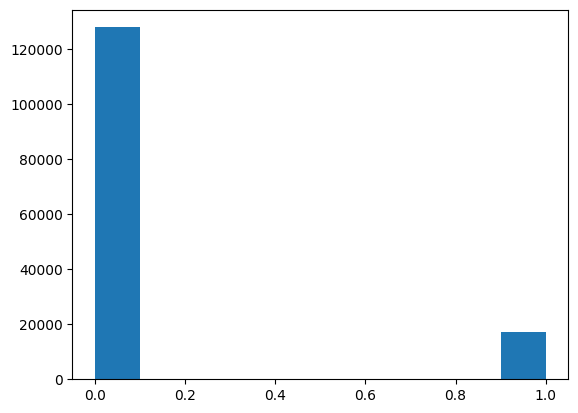

In [53]:
plt.hist(new_page_converted)
plt.show()

In [54]:
old_page_converted = np.random.choice([1, 0], size = (len(dt2_control)), p = [dt2['converted'].mean(), 1 - dt2['converted'].mean()])
print(len(old_page_converted[old_page_converted == 1])/len(old_page_converted))
print(len(old_page_converted[old_page_converted == 0])/len(old_page_converted))

0.11890634249762518
0.8810936575023748


In [57]:
new_page_converted = np.random.binomial(len(dt2_treatment), dt2['converted'].mean(), size = 10000) / len(dt2_treatment)
old_page_converted = np.random.binomial(len(dt2_control), dt2['converted'].mean(), size = 10000) / len(dt2_control)

In [59]:
p_diff = new_page_converted - old_page_converted

In [61]:
print(f"p_diff mean : {p_diff.mean()}")
print(f"p_diff std : {p_diff.std()}")

p_diff mean : -7.87876771118602e-06
p_diff std : 0.0011993959912133712


In [63]:
ab_data_diff = dt2_treatment['converted'].mean() - dt2_control['converted'].mean()
print(f"ab_data_diff : {ab_data_diff}")

ab_data_diff : -0.0015782389853555567


In [65]:
len(p_diff[p_diff >= ab_data_diff])/len(p_diff) * 100

90.42999999999999

In [66]:
len(p_diff[p_diff < ab_data_diff])/len(p_diff) * 100

9.569999999999999

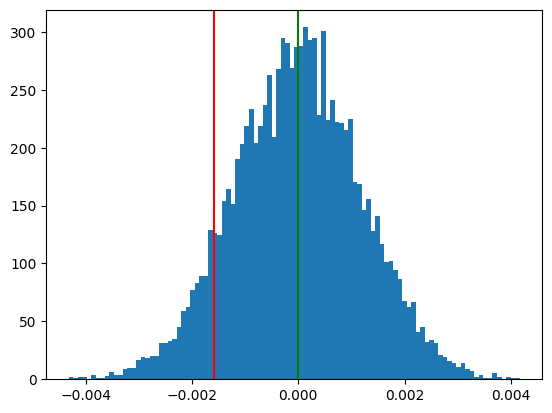

In [68]:
plt.hist(p_diff, bins = 100)
low = ab_data_diff
high = p_diff.mean()
plt.axvline(low, color = 'red')
plt.axvline(high, color = 'green')
plt.show()